In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def load_data():
    # Load normal period data (2023-2025)
    spy = pd.read_excel('data.xlsx', sheet_name='SPY', usecols=['Date', 'Adj Close'], parse_dates=['Date'])
    efa = pd.read_excel('data.xlsx', sheet_name='EFA', usecols=['Date', 'Adj Close'], parse_dates=['Date'])
    fxi = pd.read_excel('data.xlsx', sheet_name='FXI', usecols=['Date', 'Adj Close'], parse_dates=['Date'])

    spy.rename(columns={'Adj Close': 'SPY_AdjClose'}, inplace=True)
    efa.rename(columns={'Adj Close': 'EFA_AdjClose'}, inplace=True)
    fxi.rename(columns={'Adj Close': 'FXI_AdjClose'}, inplace=True)

    df_price = pd.merge(spy, efa, on='Date', how='inner')
    df_price = pd.merge(df_price, fxi, on='Date', how='inner')
    df_price.sort_values('Date', inplace=True)
    df_price.reset_index(drop=True, inplace=True)

    # Load stressed period data (2007-2009)
    spy_stress = pd.read_excel('data.xlsx', sheet_name='SPY_stressed', usecols=['Date', 'Adj Close'], parse_dates=['Date'])
    efa_stress = pd.read_excel('data.xlsx', sheet_name='EFA_stressed', usecols=['Date', 'Adj Close'], parse_dates=['Date'])
    fxi_stress = pd.read_excel('data.xlsx', sheet_name='FXI_stressed', usecols=['Date', 'Adj Close'], parse_dates=['Date'])

    spy_stress.rename(columns={'Adj Close': 'SPY_AdjClose'}, inplace=True)
    efa_stress.rename(columns={'Adj Close': 'EFA_AdjClose'}, inplace=True)
    fxi_stress.rename(columns={'Adj Close': 'FXI_AdjClose'}, inplace=True)

    df_stress_price = pd.merge(spy_stress, efa_stress, on='Date', how='inner')
    df_stress_price = pd.merge(df_stress_price, fxi_stress, on='Date', how='inner')
    df_stress_price.sort_values('Date', inplace=True)
    df_stress_price.reset_index(drop=True, inplace=True)

    return df_price, df_stress_price

df_price, df_stress_price = load_data()

In [3]:
# Count valid trading days with complete data for all three ETFs
df_2025 = df_price[(df_price['Date'] >= '2025-01-01') & (df_price['Date'] <= '2025-12-31')].copy()
M = len(df_2025)
print(f"Number of effective trading days in 2025 (M) = {M}")
# Result: M = 250

Number of effective trading days in 2025 (M) = 250


In [4]:
# Compute daily price ratios: y_n / y_{n-1}
df_price['SPY_Ratio'] = df_price['SPY_AdjClose'] / df_price['SPY_AdjClose'].shift(1)
df_price['EFA_Ratio'] = df_price['EFA_AdjClose'] / df_price['EFA_AdjClose'].shift(1)
df_price['FXI_Ratio'] = df_price['FXI_AdjClose'] / df_price['FXI_AdjClose'].shift(1)

df_ratio_period = df_price[(df_price['Date'] >= '2023-01-04') & (df_price['Date'] <= '2025-12-31')].copy()

stats_result = pd.DataFrame({
    'Ticker': ['SPY', 'EFA', 'FXI'],
    'Mean Daily Ratio': [
        df_ratio_period['SPY_Ratio'].mean(),
        df_ratio_period['EFA_Ratio'].mean(),
        df_ratio_period['FXI_Ratio'].mean()
    ],
    'Sample Std Dev': [
        df_ratio_period['SPY_Ratio'].std(ddof=1),
        df_ratio_period['EFA_Ratio'].std(ddof=1),
        df_ratio_period['FXI_Ratio'].std(ddof=1)
    ]
})
print(stats_result.round(6))

  Ticker  Mean Daily Ratio  Sample Std Dev
0    SPY          1.000875        0.009670
1    EFA          1.000664        0.009033
2    FXI          1.000620        0.018289


In [5]:
holdings = {'SPY': 800, 'EFA': 28000, 'FXI': 25000}
df_end = df_price[df_price['Date'] == '2025-12-31'].iloc[0]

spy_mv = holdings['SPY'] * df_end['SPY_AdjClose']
efa_mv = holdings['EFA'] * df_end['EFA_AdjClose']
fxi_mv = holdings['FXI'] * df_end['FXI_AdjClose']
total_portfolio_value = spy_mv + efa_mv + fxi_mv

print(f"SPY market value (2025-12-31): ${spy_mv:,.2f}")
print(f"EFA market value (2025-12-31): ${efa_mv:,.2f}")
print(f"FXI market value (2025-12-31): ${fxi_mv:,.2f}")
print(f"Total portfolio value (2025-12-31): ${total_portfolio_value:,.2f}")

SPY market value (2025-12-31): $545,535.99
EFA market value (2025-12-31): $2,688,839.97
FXI market value (2025-12-31): $957,250.02
Total portfolio value (2025-12-31): $4,191,625.98


In [6]:
# Historical Simulation: 500-scenario rolling window
end_date = '2025-12-31'
end_idx = df_price[df_price['Date'] == end_date].index[0]
window_data = df_price.iloc[end_idx - 500: end_idx + 1].copy()

window_data['SPY_Scenario_Ratio'] = window_data['SPY_AdjClose'] / window_data['SPY_AdjClose'].shift(1)
window_data['EFA_Scenario_Ratio'] = window_data['EFA_AdjClose'] / window_data['EFA_AdjClose'].shift(1)
window_data['FXI_Scenario_Ratio'] = window_data['FXI_AdjClose'] / window_data['FXI_AdjClose'].shift(1)

scenario_ratios = window_data.dropna()[['SPY_Scenario_Ratio', 'EFA_Scenario_Ratio', 'FXI_Scenario_Ratio']].values
current_mv = np.array([spy_mv, efa_mv, fxi_mv])

# PnL under each historical scenario
scenario_pnl = np.dot(scenario_ratios, current_mv) - current_mv.sum()

confidence_level = 0.99
var_99 = -np.percentile(scenario_pnl, q=100 * (1 - confidence_level), method='linear')
print(f"1-day 99% VaR (DEAR) on 2025-12-31: ${var_99:,.2f}")

1-day 99% VaR (DEAR) on 2025-12-31: $96,866.13


In [7]:
# Compute DEAR for last trading day of 2024 and every trading day in 2025
last_day_2024 = df_price[df_price['Date'] < '2025-01-01']['Date'].max()
calc_dates = pd.concat([
    df_price[df_price['Date'] == last_day_2024]['Date'],
    df_2025['Date']
]).reset_index(drop=True)

dear_results = pd.DataFrame(columns=['Date', '1-day 99% DEAR'])

for idx, date in enumerate(calc_dates):
    current_idx = df_price[df_price['Date'] == date].index[0]
    if current_idx < 500:
        continue

    window = df_price.iloc[current_idx - 500: current_idx + 1].copy()
    window['SPY_Ratio'] = window['SPY_AdjClose'] / window['SPY_AdjClose'].shift(1)
    window['EFA_Ratio'] = window['EFA_AdjClose'] / window['EFA_AdjClose'].shift(1)
    window['FXI_Ratio'] = window['FXI_AdjClose'] / window['FXI_AdjClose'].shift(1)

    scenario_ratios = window.dropna()[['SPY_Ratio', 'EFA_Ratio', 'FXI_Ratio']].values

    # Portfolio value at end of current day
    current_spy_mv = holdings['SPY'] * window.iloc[-1]['SPY_AdjClose']
    current_efa_mv = holdings['EFA'] * window.iloc[-1]['EFA_AdjClose']
    current_fxi_mv = holdings['FXI'] * window.iloc[-1]['FXI_AdjClose']
    current_mv = np.array([current_spy_mv, current_efa_mv, current_fxi_mv])

    scenario_pnl = np.dot(scenario_ratios, current_mv) - current_mv.sum()
    dear = -np.percentile(scenario_pnl, q=1, method='linear')
    dear_results.loc[idx] = [date, dear]

print("=== First 5 DEAR results ===")
print(dear_results.head().round(2))
print("\n=== Last 5 DEAR results ===")
print(dear_results.tail().round(2))
dear_results.to_csv('dear_results.csv', index=False)

=== First 5 DEAR results ===
        Date  1-day 99% DEAR
0 2024-12-31        67313.63
1 2025-01-02        66752.41
2 2025-01-03        67374.78
3 2025-01-06        67471.73
4 2025-01-07        67089.37

=== Last 5 DEAR results ===
          Date  1-day 99% DEAR
246 2025-12-24        97421.30
247 2025-12-26        97968.60
248 2025-12-29        97244.84
249 2025-12-30        97563.15
250 2025-12-31        96866.13


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_22120\2305690482.py:33: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(dear_results.head().round(2))
C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_22120\2305690482.py:35: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(dear_results.tail().round(2))


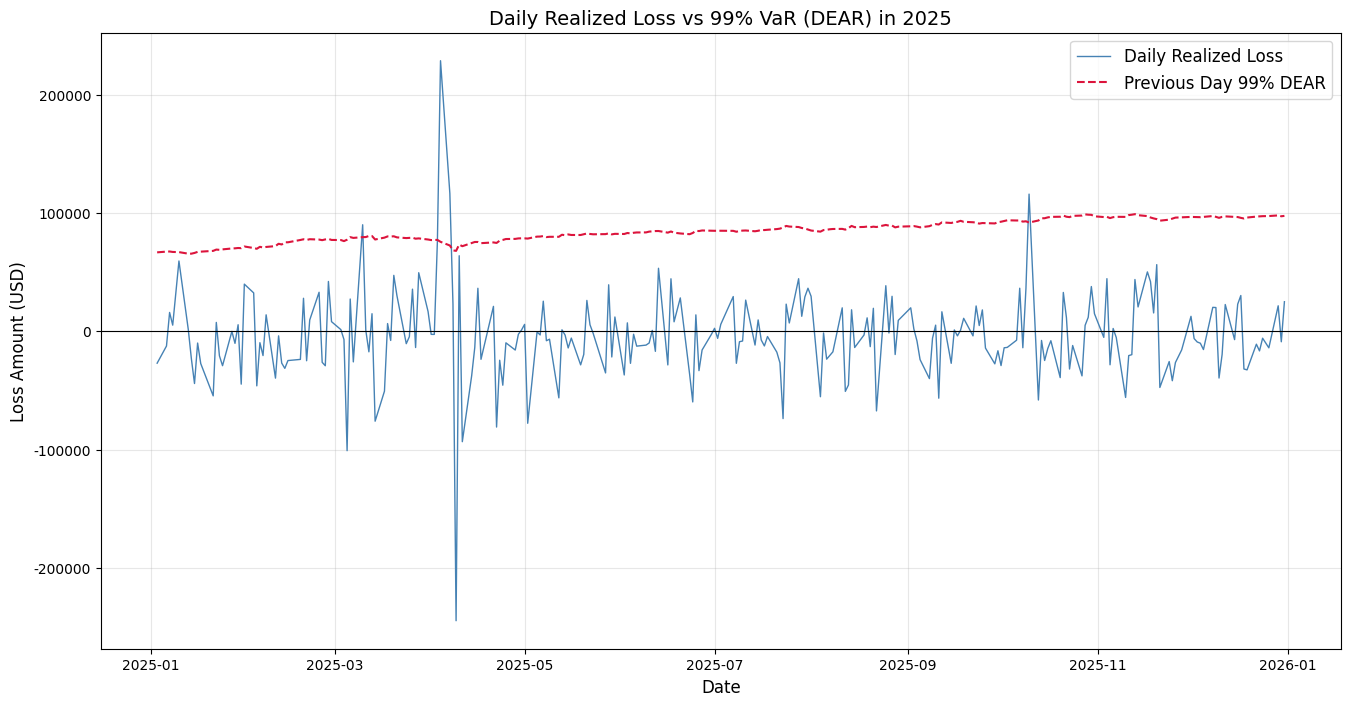

Date of maximum daily loss in 2025: 2025-04-04
Maximum daily loss amount: $228,677.16

=== PnL contribution on maximum loss day ===
SPY contribution: $-24,918.97
EFA contribution: $-143,277.40
FXI contribution: $-60,480.79


In [8]:
# Compute daily realized portfolio losses
df_2025['SPY_MV'] = holdings['SPY'] * df_2025['SPY_AdjClose']
df_2025['EFA_MV'] = holdings['EFA'] * df_2025['EFA_AdjClose']
df_2025['FXI_MV'] = holdings['FXI'] * df_2025['FXI_AdjClose']
df_2025['Total_MV'] = df_2025['SPY_MV'] + df_2025['EFA_MV'] + df_2025['FXI_MV']
df_2025['Daily_PnL'] = df_2025['Total_MV'] - df_2025['Total_MV'].shift(1)
df_2025['Realized_Loss'] = -df_2025['Daily_PnL']
df_2025 = df_2025.dropna().reset_index(drop=True)

dear_results = pd.read_csv('dear_results.csv', parse_dates=['Date'])

# Align each day's realized loss with previous day's DEAR
df_backtest = pd.merge(
    df_2025[['Date', 'Realized_Loss']],
    dear_results.rename(columns={'Date': 'Prev_Date', '1-day 99% DEAR': 'Prev_Day_DEAR'}),
    left_on='Date',
    right_on=dear_results['Date'].shift(-1),
    how='inner'
)

# Plot realized losses vs DEAR
plt.figure(figsize=(16, 8))
plt.plot(df_backtest['Date'], df_backtest['Realized_Loss'],
         label='Daily Realized Loss', color='steelblue', linewidth=1)
plt.plot(df_backtest['Date'], df_backtest['Prev_Day_DEAR'],
         label='Previous Day 99% DEAR', color='crimson', linestyle='--', linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.title('Daily Realized Loss vs 99% VaR (DEAR) in 2025', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Loss Amount (USD)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.savefig('var_backtest_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Identify maximum loss day and per-asset contribution
max_loss_row = df_backtest.loc[df_backtest['Realized_Loss'].idxmax()]
max_loss_date = max_loss_row['Date']
print(f"Date of maximum daily loss in 2025: {max_loss_date.date()}")
print(f"Maximum daily loss amount: ${max_loss_row['Realized_Loss']:,.2f}")

max_loss_date_idx = df_2025[df_2025['Date'] == max_loss_date].index[0]
prev_day_data = df_2025.iloc[max_loss_date_idx - 1]
current_day_data = df_2025.iloc[max_loss_date_idx]

spy_contribution = current_day_data['SPY_MV'] - prev_day_data['SPY_MV']
efa_contribution = current_day_data['EFA_MV'] - prev_day_data['EFA_MV']
fxi_contribution = current_day_data['FXI_MV'] - prev_day_data['FXI_MV']

print("\n=== PnL contribution on maximum loss day ===")
print(f"SPY contribution: ${spy_contribution:,.2f}")
print(f"EFA contribution: ${efa_contribution:,.2f}")
print(f"FXI contribution: ${fxi_contribution:,.2f}")

In [9]:
# Count exceptions: days where realized loss > previous day's DEAR
exception_events = df_backtest[df_backtest['Realized_Loss'] > df_backtest['Prev_Day_DEAR']].copy()
exception_count = len(exception_events)
print(f"Number of 99% DEAR backtest exceptions in 2025: {exception_count}")
print("Exception details:")
print(exception_events[['Date', 'Realized_Loss', 'Prev_Day_DEAR']].round(2))

# Basel traffic light mapping
basel_mapping = {
    range(0, 5): 3.0, 5: 3.4, 6: 3.5,
    7: 3.65, 8: 3.75, 9: 3.85,
    range(10, 1000): 4.0
}

def get_mc(exception_count):
    for key in basel_mapping:
        if isinstance(key, range) and exception_count in key:
            return basel_mapping[key]
        elif isinstance(key, int) and exception_count == key:
            return basel_mapping[key]
    return 4.0

mc = get_mc(exception_count)

if exception_count <= 4:
    zone = 'Green Zone'
elif 5 <= exception_count <= 9:
    zone = 'Yellow Zone'
else:
    zone = 'Red Zone'

print(f"Basel traffic light zone: {zone}")
print(f"Corresponding multiplier factor mc = {mc}")

Number of 99% DEAR backtest exceptions in 2025: 4
Exception details:
          Date  Realized_Loss  Prev_Day_DEAR
43  2025-03-10       90069.59       79604.56
62  2025-04-04      228677.16       75645.44
63  2025-04-07      116465.87       72545.14
192 2025-10-10      115962.10       91928.93
Basel traffic light zone: Green Zone
Corresponding multiplier factor mc = 3.0


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_22120\1849236568.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(exception_events[['Date', 'Realized_Loss', 'Prev_Day_DEAR']].round(2))


Number of fixed stressed scenarios generated: 250


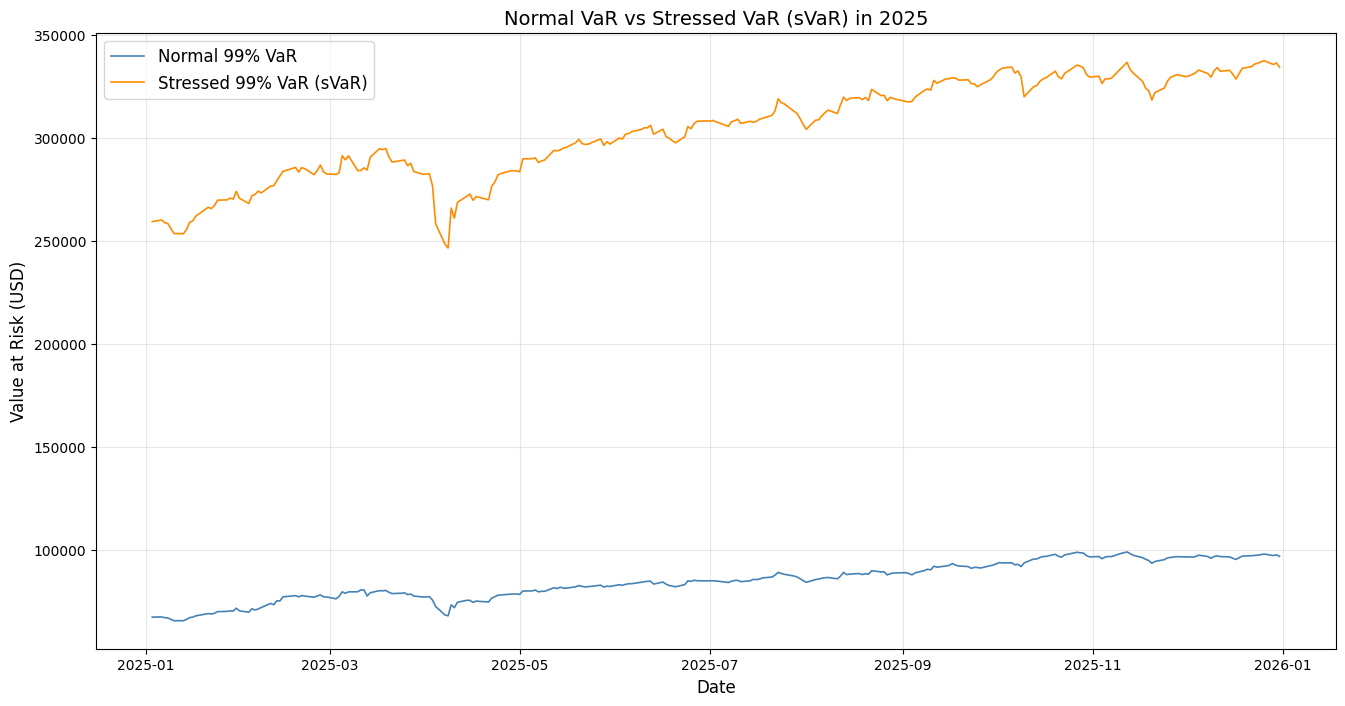

In [10]:
# Generate 250 fixed stressed scenarios from 2008 financial crisis
df_2008_stress = df_stress_price[
    (df_stress_price['Date'] >= '2008-07-01') & (df_stress_price['Date'] <= '2009-06-30')
].copy()

if len(df_2008_stress) < 251:
    raise ValueError("Insufficient stressed period data!")

stress_window = df_2008_stress.iloc[0:251].copy()
stress_window['SPY_Stress_Ratio'] = stress_window['SPY_AdjClose'] / stress_window['SPY_AdjClose'].shift(1)
stress_window['EFA_Stress_Ratio'] = stress_window['EFA_AdjClose'] / stress_window['EFA_AdjClose'].shift(1)
stress_window['FXI_Stress_Ratio'] = stress_window['FXI_AdjClose'] / stress_window['FXI_AdjClose'].shift(1)

stress_ratios = stress_window.dropna()[['SPY_Stress_Ratio', 'EFA_Stress_Ratio', 'FXI_Stress_Ratio']].values
print(f"Number of fixed stressed scenarios generated: {len(stress_ratios)}")

# Calculate sVaR for each trading day in 2025
svar_results = pd.DataFrame(columns=['Date', '1-day 99% Stressed VaR (sVaR)'])

for idx, date in enumerate(df_2025['Date']):
    current_data = df_2025[df_2025['Date'] == date].iloc[0]
    current_spy_mv = holdings['SPY'] * current_data['SPY_AdjClose']
    current_efa_mv = holdings['EFA'] * current_data['EFA_AdjClose']
    current_fxi_mv = holdings['FXI'] * current_data['FXI_AdjClose']
    current_mv = np.array([current_spy_mv, current_efa_mv, current_fxi_mv])

    stress_pnl = np.dot(stress_ratios, current_mv) - current_mv.sum()
    svar = -np.percentile(stress_pnl, q=1, method='linear')
    svar_results.loc[idx] = [date, svar]

# Plot Normal VaR vs Stressed VaR
var_svar_compare = pd.merge(
    dear_results.rename(columns={'1-day 99% DEAR': 'Normal VaR'}),
    svar_results,
    on='Date',
    how='inner'
)

plt.figure(figsize=(16, 8))
plt.plot(var_svar_compare['Date'], var_svar_compare['Normal VaR'],
         label='Normal 99% VaR', color='steelblue', linewidth=1.2)
plt.plot(var_svar_compare['Date'], var_svar_compare['1-day 99% Stressed VaR (sVaR)'],
         label='Stressed 99% VaR (sVaR)', color='darkorange', linewidth=1.2)
plt.title('Normal VaR vs Stressed VaR (sVaR) in 2025', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value at Risk (USD)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.savefig('var_svar_compare_plot.png', dpi=300, bbox_inches='tight')
plt.show()

svar_results.to_csv('svar_results.csv', index=False)

In [11]:
# Load saved VaR and sVaR results
if not os.path.exists('dear_results.csv'):
    raise FileNotFoundError("dear_results.csv not found!")
if not os.path.exists('svar_results.csv'):
    raise FileNotFoundError("svar_results.csv not found!")

dear_results = pd.read_csv('dear_results.csv', parse_dates=['Date'])
svar_results = pd.read_csv('svar_results.csv', parse_dates=['Date'])

end_date = '2025-12-31'

# 60-day rolling average window ending on 2025-12-31
var_60_window = dear_results[dear_results['Date'] <= end_date].tail(60).copy()
svar_60_window = svar_results[svar_results['Date'] <= end_date].tail(60).copy()

if len(var_60_window) < 60 or len(svar_60_window) < 60:
    raise ValueError("Insufficient VaR/sVaR data for 60-day window!")

VaR_end = var_60_window.iloc[-1]['1-day 99% DEAR']
VaR_avg = var_60_window['1-day 99% DEAR'].mean()
sVaR_end = svar_60_window.iloc[-1]['1-day 99% Stressed VaR (sVaR)']
sVaR_avg = svar_60_window['1-day 99% Stressed VaR (sVaR)'].mean()
mc = get_mc(exception_count)

# Basel 2.5 capital charge formula
term1 = max(VaR_end, mc * VaR_avg)
term2 = max(sVaR_end, mc * sVaR_avg)
capital_charge = math.sqrt(10) * (term1 + term2)

print("=== Core capital charge parameters ===")
print(f"1-day 99% VaR on 2025-12-31: ${VaR_end:,.2f}")
print(f"Average VaR over last 60 trading days: ${VaR_avg:,.2f}")
print(f"1-day 99% sVaR on 2025-12-31: ${sVaR_end:,.2f}")
print(f"Average sVaR over last 60 trading days: ${sVaR_avg:,.2f}")
print(f"Basel multiplier factor mc: {mc}")
print("\n=== Final Market Risk Capital Charge ===")
print(f"Market risk capital charge: ${capital_charge:,.2f}")

=== Core capital charge parameters ===
1-day 99% VaR on 2025-12-31: $96,866.13
Average VaR over last 60 trading days: $96,512.83
1-day 99% sVaR on 2025-12-31: $334,194.69
Average sVaR over last 60 trading days: $330,337.88
Basel multiplier factor mc: 3.0

=== Final Market Risk Capital Charge ===
Market risk capital charge: $4,049,461.33
